# Contrastive Learning — AdaptMap (Paper Faithful)

Implementazione PyTorch Lightning **completamente fedele** al paper:
> Thor & Nettelblad (2025) — *"Dimensionality Reduction of Genetic Data using Contrastive Learning"*

---

### Differenze rispetto a `contrastive_adaptmap.ipynb`

| Componente | Versione naïve | Versione paper-faithful |
|---|---|---|
| **Loss** (bug critico) | `log(1+clamp(term))` per-pair | `log(1 + Σ_i term_i)` — somma **dentro** il log (Eq. 6) |
| **Batch size** | 128 (mini-batch, 5 iter/epoch) | **Full-batch** (`len(X_train)`) — 1 iter/epoch |
| **Negativi** | 127 per anchor | **N_train − 1** per anchor (tutti gli altri) |
| **Optimizer** | AdamW | **Adam** β₁=0.9, β₂=0.999 (nessun weight decay) |
| **LR decay** | ExponentialLR ogni epoch | **StepLR** γ=0.99 ogni **10 epoche** |
| **Augmentation** | flip=mask=0.90, U(0.001,·) | flip=mask=0.99, **U(0.01, 0.99)** |
| **Epochs** | 100 | **5000** |


## 📦 Installazione Dipendenze

In [1]:
# !pip install pytorch-lightning bed-reader scikit-learn matplotlib seaborn pandas numpy


## 📚 Import

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, silhouette_score, davies_bouldin_score
from bed_reader import open_bed
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

pl.seed_everything(42)
print(f"PyTorch:           {torch.__version__}")
print(f"PyTorch Lightning: {pl.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")


import sys
# Repo root importabile per importare il package contrastive_learning
sys.path.insert(0, os.path.dirname(os.getcwd()))

from contrastive_learning import (
    GenomicDataModule,
    GeneticAugmentation,
    GeneticEncoder,
    CentroidNPairLoss,
    ContrastiveGeneticModel,
    run_experiment,
    extract_embeddings,
    compute_metrics,
    equal_earth_projection,
    plot_distribution,
    plot_embedding,
    plot_confusion_matrix,
)


## 🧬 Core implementation

La logica core (DataModule, augmentation, encoder, loss, modello,
`run_experiment`, metriche e plotting) è stata estratta nel package
`contrastive_learning` e importata nella cella degli import.

Restano inline solo: configurazione, esecuzione, visualizzazione e
Integrated Gradients / attribuzione.


## ⚙️ Configurazione — Paper Faithful

In [ ]:
BED_PATH          = "../data/ADAPTmap_genotypeTOP_20160222_full.bed"
SAMPLES_PER_CLASS = 30

config = {
    # === Architettura ===
    'embedding_dim':     3,        # paper: sfera 3D

    # === Augmentation — paper: U(0.01, 0.99) ===
    'flip_max':          0.99,     # p_flip_max
    'mask_max':          0.99,     # p_mask_max

    # === Optimizer — paper: Adam β₁=0.9, β₂=0.999, lr=0.001 ===
    'learning_rate':     0.001,
    'lr_decay_factor':   0.99,     # paper: decay 0.99
    'lr_decay_interval': 10,       # paper: ogni 10 iterazioni

    # === Training — paper: 5000 epoche, full-batch ===
    'max_epochs':        5000,
    'k_folds':           3,

    # === Hardware ===
    'accelerator':  'gpu' if torch.cuda.is_available() else 'cpu',
    'devices':      1,
}

# batch_size NON è nel config: viene determinato dinamicamente
# in run_experiment come len(X_train) — paper: full-batch

print("✅ Config paper-faithful:")
for k, v in config.items():
    print(f"   {k:25s}: {v}")

dm = GenomicDataModule(
    bed_path              = BED_PATH,
    batch_size            = 2048,          # full-batch
    maf_thresh            = 0.01,          # (allineato con VAE che usa 0.01)
    geno_thresh           = 0.1,           # (allineato con VAE che usa 0.1)
    min_samples_per_class = SAMPLES_PER_CLASS,
    ld_pruning            = True,
    ld_threshold          = 0.2,
    ld_window             = 50,
    val_split             = 0.15,
    test_split            = 0.15,
    downsample_per_class  = None,          # (il VAE non faceva downsampling prima del QC, rimuovendolo allineiamo i calcoli MAF)
)
dm.setup()


✅ Config paper-faithful:
   embedding_dim            : 3
   flip_max                 : 0.99
   mask_max                 : 0.99
   learning_rate            : 0.001
   lr_decay_factor          : 0.99
   lr_decay_interval        : 10
   max_epochs               : 5000
   k_folds                  : 3
   accelerator              : gpu
   devices                  : 1

CARICAMENTO: ../data/ADAPTmap_genotypeTOP_20160222_full.bed
📊 Shape iniziale: (4653, 53347)
🔍 Razze ≥30 campioni: 34/144

🧬 QC PIPELINE
   1. Missingness: 51205 SNP rimasti
   2. Imputazione: OK
   3. MAF: 51201 SNP rimasti
   4. LD Pruning (window=50, r²>0.2)...


In [ ]:
plot_distribution(dm.y_processed, dm.class_names,
                  title=f"AdaptMap — {SAMPLES_PER_CLASS} campioni/razza "
                        f"({dm.num_classes} razze, {len(dm.X_processed)} totale, {dm.num_snps} SNP)")


## 🚀 Training

- **1 iterazione per epoch** (full-batch)
- LR: 0.001 → ~6.7×10⁻⁶ dopo 5000 epoche (`0.001 × 0.99^500`)
- GPU A100: ~1.3 s/epoch (come riportato nel paper per il dataset cani)
- Early stopping `patience=200` come salvaguardia (non menzionato nel paper)


In [ ]:
result = run_experiment(
    name       = 'Original',
    dm         = dm,
    config     = config,
    max_epochs = config['max_epochs'],
    k_folds    = config['k_folds'],
)


In [ ]:
display_cols = ['Experiment'] + [c for c in result if '(mean)' in c]
df = pd.DataFrame([{k: result[k] for k in display_cols}])
os.makedirs('results', exist_ok=True)
df.to_csv('results/adaptmap_paperfaithful.csv', index=False)

print("\n📊 RISULTATI PAPER-FAITHFUL:")
print(df.to_string(index=False))
print("\n💾 Salvato: results/adaptmap_paperfaithful.csv")


## 🌍 Visualizzazione — Proiezione Equal Earth

In [ ]:
best_Z = result.get('_best_Z')
best_y = result.get('_best_y')

if best_Z is not None:
    plot_embedding(best_Z, best_y, dm.class_names)


## 📊 Confusion Matrix KNN@3

In [ ]:
if best_Z is not None:
    plot_confusion_matrix(best_Z, best_y, dm.class_names)


## 🔬 Explainable AI — Integrated Gradients

**Obiettivo:** Identificare quali SNP sono più *discriminanti* per la classificazione di una razza caprina.

### Strategia

Il modello Contrastivo è **self-supervised** (nessun output di classe). Per applicare IG aggiungiamo un **Linear Probe** (regressione logistica) addestrato sugli embedding `_best_Z`.

Pipeline differenziabile:
```
x_one_hot (1,M,4) → GeneticEncoder → z (1,3) → StandardScaler → LinearProbe → logit (1,C)
```

La **baseline** è il vettore zero. L'importanza per SNP è la **norma L1 sui 4 canali allelici**.

> `GeneticAugmentation.one_hot_encode` è usato solo come preprocessing *fuori* dal grafo autograd.

In [ ]:
# ============================================================
# EXPLAINABLE AI — Integrated Gradients (One-Hot Space)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as tts
import torch.optim as optim
import glob

# ── Inizializza DataModule se necessario ─────────────────────
if 'dm' not in globals() or not hasattr(dm, 'X_processed'):
    print("⏳ Setup del DataModule necessario...")
    SAMPLES_PER_CLASS = 30
    BED_PATH = "../data/ADAPTmap_genotypeTOP_20160222_full.bed"
    dm = GenomicDataModule(
        bed_path              = BED_PATH,
        batch_size            = 512,
        maf_thresh            = 0.01,
        geno_thresh           = 0.1,
        min_samples_per_class = SAMPLES_PER_CLASS,
        ld_pruning            = True,
        ld_threshold          = 0.2,
        ld_window             = 50,
        val_split             = 0.15,
        test_split            = 0.15,
        downsample_per_class  = None,
    )
    dm.setup()

# ── Individua il miglior checkpoint ──────────────────────────
checkpoints = glob.glob("checkpoints/Original/fold_*/epoch=*-val_loss=*.ckpt")
best_ckpt   = None
best_acc    = -1

for ckpt in checkpoints:
    m   = ContrastiveGeneticModel.load_from_checkpoint(ckpt)
    Z   = extract_embeddings(m, dm.X_processed)
    acc = compute_metrics(Z, dm.y_processed, k=3)['knn_acc_k3']
    print(f"{ckpt} → KNN@3 = {acc:.4f}")
    if acc > best_acc:
        best_acc, best_ckpt = acc, ckpt

print(f"\nMiglior checkpoint: {best_ckpt} (KNN@3={best_acc:.4f})")
best_model = ContrastiveGeneticModel.load_from_checkpoint(best_ckpt)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = best_model.to(device)
best_model.eval()

# ── Parte 1: Linear Probe (LogReg) ───────────────────────────
skf           = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X, y          = dm.X_processed, dm.y_processed
folds         = list(skf.split(X, y))
best_fold_idx = int(best_ckpt.split('fold_')[1].split('/')[0]) - 1
tr_idx, val_idx = folds[best_fold_idx]
print(f"Fold usato per il probe: {best_fold_idx + 1}")

best_Z = extract_embeddings(best_model, X[val_idx])
best_y = y[val_idx]

# ============================================================
# PROBE MLP
# ============================================================

MLP_EPOCHS = 300
MLP_LR     = 1e-3
MLP_BATCH  = 256
MLP_HIDDEN = 64

Z_tr, Z_val_mlp, y_tr, y_val_mlp = tts(
    best_Z, best_y, test_size=0.20, stratify=best_y, random_state=42
)
scaler_mlp  = StandardScaler().fit(Z_tr)
Z_tr_s      = scaler_mlp.transform(Z_tr).astype(np.float32)
Z_val_mlp_s = scaler_mlp.transform(Z_val_mlp).astype(np.float32)

tr_ds  = TensorDataset(torch.FloatTensor(Z_tr_s),      torch.LongTensor(y_tr))
val_ds = TensorDataset(torch.FloatTensor(Z_val_mlp_s), torch.LongTensor(y_val_mlp))
tr_dl  = DataLoader(tr_ds,  batch_size=MLP_BATCH, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=MLP_BATCH)

probe_mlp = nn.Sequential(
    nn.Linear(3, MLP_HIDDEN), nn.BatchNorm1d(MLP_HIDDEN), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(MLP_HIDDEN, MLP_HIDDEN), nn.BatchNorm1d(MLP_HIDDEN), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(MLP_HIDDEN, dm.num_classes)
).to(device)

optimizer = optim.Adam(probe_mlp.parameters(), lr=MLP_LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MLP_EPOCHS)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
best_state   = None

for epoch in range(MLP_EPOCHS):
    probe_mlp.train()
    for Zb, yb in tr_dl:
        Zb, yb = Zb.to(device), yb.to(device)
        optimizer.zero_grad()
        criterion(probe_mlp(Zb), yb).backward()
        optimizer.step()
    scheduler.step()

    probe_mlp.eval()
    correct = total = 0
    with torch.no_grad():
        for Zb, yb in val_dl:
            preds = probe_mlp(Zb.to(device)).argmax(dim=1).cpu()
            correct += (preds == yb).sum().item()
            total   += len(yb)
    val_acc = correct / total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.clone() for k, v in probe_mlp.state_dict().items()}

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}/{MLP_EPOCHS} | val_acc={val_acc:.4f} | best={best_val_acc:.4f}")

probe_mlp.load_state_dict(best_state)
probe_mlp.eval()
print(f"\nProbe MLP — Best val acc: {best_val_acc:.4f}")

class EncoderWithProbeMLP(nn.Module):
    def __init__(self, encoder, sc_mean, sc_std, probe):
        super().__init__()
        self.encoder = encoder
        self.probe   = probe
        self.register_buffer('sc_mean', torch.FloatTensor(sc_mean))
        self.register_buffer('sc_std',  torch.FloatTensor(sc_std))

    def forward(self, x_one_hot):
        z        = self.encoder(x_one_hot)
        z_scaled = (z - self.sc_mean) / (self.sc_std + 1e-8)
        return self.probe(z_scaled)

enc_probe_mlp = EncoderWithProbeMLP(
    encoder = best_model.encoder,
    sc_mean = scaler_mlp.mean_.astype(np.float32),
    sc_std  = scaler_mlp.scale_.astype(np.float32),
    probe   = probe_mlp,
).to(device).eval()

# ============================================================
# GLOBAL IG — Media su tutti i campioni / tutte le razze
# ============================================================

def compute_ig_batched(model, X_snps, target_classes, baseline_val=0.0,
                        n_steps=50, batch_size=32):
    N, M   = X_snps.shape
    ig_all = np.zeros((N, M), dtype=np.float32)
    alphas = torch.linspace(0.0, 1.0, n_steps + 1, device=device)

    model.eval()
    for start in range(0, N, batch_size):
        end     = min(start + batch_size, N)
        B       = end - start
        x_batch = torch.FloatTensor(X_snps[start:end]).to(device)
        t_batch = target_classes[start:end]

        with torch.no_grad():
            x_oh_b = GeneticAugmentation.one_hot_encode(x_batch).float()
        baseline = torch.full_like(x_oh_b, baseline_val)
        diff     = x_oh_b - baseline

        grads_list = []
        for alpha in alphas:
            interp = (baseline + alpha * diff).requires_grad_(True)
            scores = model(interp)
            score  = scores[torch.arange(B, device=device), t_batch].sum()
            model.zero_grad()
            score.backward()
            grads_list.append(interp.grad.detach().clone())

        gs        = torch.stack(grads_list)
        avg_grads = (gs[0] + gs[-1]) / 2.0 + gs[1:-1].sum(0)
        avg_grads /= n_steps

        ig_map           = diff * avg_grads
        ig_all[start:end] = ig_map.abs().sum(dim=-1).cpu().numpy()

        if (end % 256 == 0) or end == N:
            print(f"  {end}/{N} campioni elaborati...")

    return ig_all

print("\nCalcolo IG globale su tutti i campioni (probe MLP)...")
ig_all = compute_ig_batched(
    model          = enc_probe_mlp,
    X_snps         = dm.X_processed,
    target_classes = torch.LongTensor(dm.y_processed).to(device),
    n_steps        = 50,
    batch_size     = 32,
)
print(f"ig_all shape: {ig_all.shape}")

# Media pesata per razza (evita bias razze numerose)
ig_per_breed = []
for cls in range(dm.num_classes):
    mask = dm.y_processed == cls
    if mask.sum() > 0:
        ig_per_breed.append(ig_all[mask].mean(axis=0))

ig_global     = np.mean(ig_per_breed, axis=0)
ig_global_std = np.std(ig_per_breed,  axis=0)

os.makedirs('results', exist_ok=True)
np.save('results/ig_global_mean.npy', ig_global)
np.save('results/ig_global_std.npy',  ig_global_std)
print("Salvato: results/ig_global_mean.npy | ig_global_std.npy")

# ── Plot globale ──────────────────────────────────────────────
snp_idx_g    = np.arange(len(ig_global))
thr_global   = np.percentile(ig_global, 99)
hot_global   = ig_global >= thr_global

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(snp_idx_g, ig_global, alpha=0.25, color='mediumseagreen')
ax.plot(snp_idx_g, ig_global, lw=0.5, color='mediumseagreen', alpha=0.8)
ax.fill_between(snp_idx_g,
                ig_global - ig_global_std,
                ig_global + ig_global_std,
                alpha=0.12, color='mediumseagreen', label='±1 std tra razze')
ax.scatter(snp_idx_g[hot_global], ig_global[hot_global],
           s=20, color='red', zorder=5,
           label=f'Top 1% SNP ({hot_global.sum()} posizioni)')
ax.axhline(thr_global, color='red', linestyle='--', lw=1.2,
           label=f'99° percentile ({thr_global:.5f})')
ax.set_title(f'Integrated Gradients — Importanza Globale (media su {dm.num_classes} razze)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Indice SNP (post QC/LD-pruning)', fontsize=11)
ax.set_ylabel('Importanza SNP media inter-razza', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('results/ig_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: results/ig_global.png")

# ── Top 20 SNP globali ────────────────────────────────────────
top20_global = np.argsort(ig_global)[::-1][:20]
print(f"\nTop 20 SNP globali (media su {dm.num_classes} razze):")
print(f"{'Rank':<5} {'SNP Index':<12} {'IG mean':<16} {'IG std'}")
print('-' * 48)
for rank, idx in enumerate(top20_global, 1):
    print(f"{rank:<5} {idx:<12} {ig_global[idx]:.8f}   {ig_global_std[idx]:.8f}")


## 🎯 Explainable AI — IG su Similarità al Centroide di Razza

**Domanda biologica diretta:** *"Quali SNP spingono questo animale verso il cluster della sua razza nello spazio sferico?"*

### Differenza rispetto al probe

| Approccio | Funzione target degli IG | Dipende da probe? |
|---|---|---|
| Probe LogReg/MLP | Logit del classificatore | ✅ Sì |
| **Centroide (questa cella)** | **Cosine similarity verso il centroide di razza** | ❌ No |

Il centroide di ogni razza è la **media normalizzata degli embedding** di tutti i suoi campioni sulla sfera unitaria. Gli IG misurano direttamente quanto ogni SNP contribuisce ad avvicinare l'animale al proprio cluster — senza intermediari, fedele alla geometria del modello Contrastivo.

L'analisi viene eseguita sia su un **campione singolo** sia in **media globale su tutte le razze**, e i risultati sono confrontati con l'approccio probe tramite Indice di Jaccard.

Riuso best_model già in memoria.
Centroidi calcolati per 34 razze.

Calcolo IG centroide globale su tutti i campioni...
  256/2976 campioni elaborati...
  512/2976 campioni elaborati...
  768/2976 campioni elaborati...
  1024/2976 campioni elaborati...
  1280/2976 campioni elaborati...
  1536/2976 campioni elaborati...
  1792/2976 campioni elaborati...
  2048/2976 campioni elaborati...
  2304/2976 campioni elaborati...
  2560/2976 campioni elaborati...
  2816/2976 campioni elaborati...
  2976/2976 campioni elaborati...
ig_all_c shape: (2976, 46453)
Salvato: results/ig_centroid_global_mean.npy


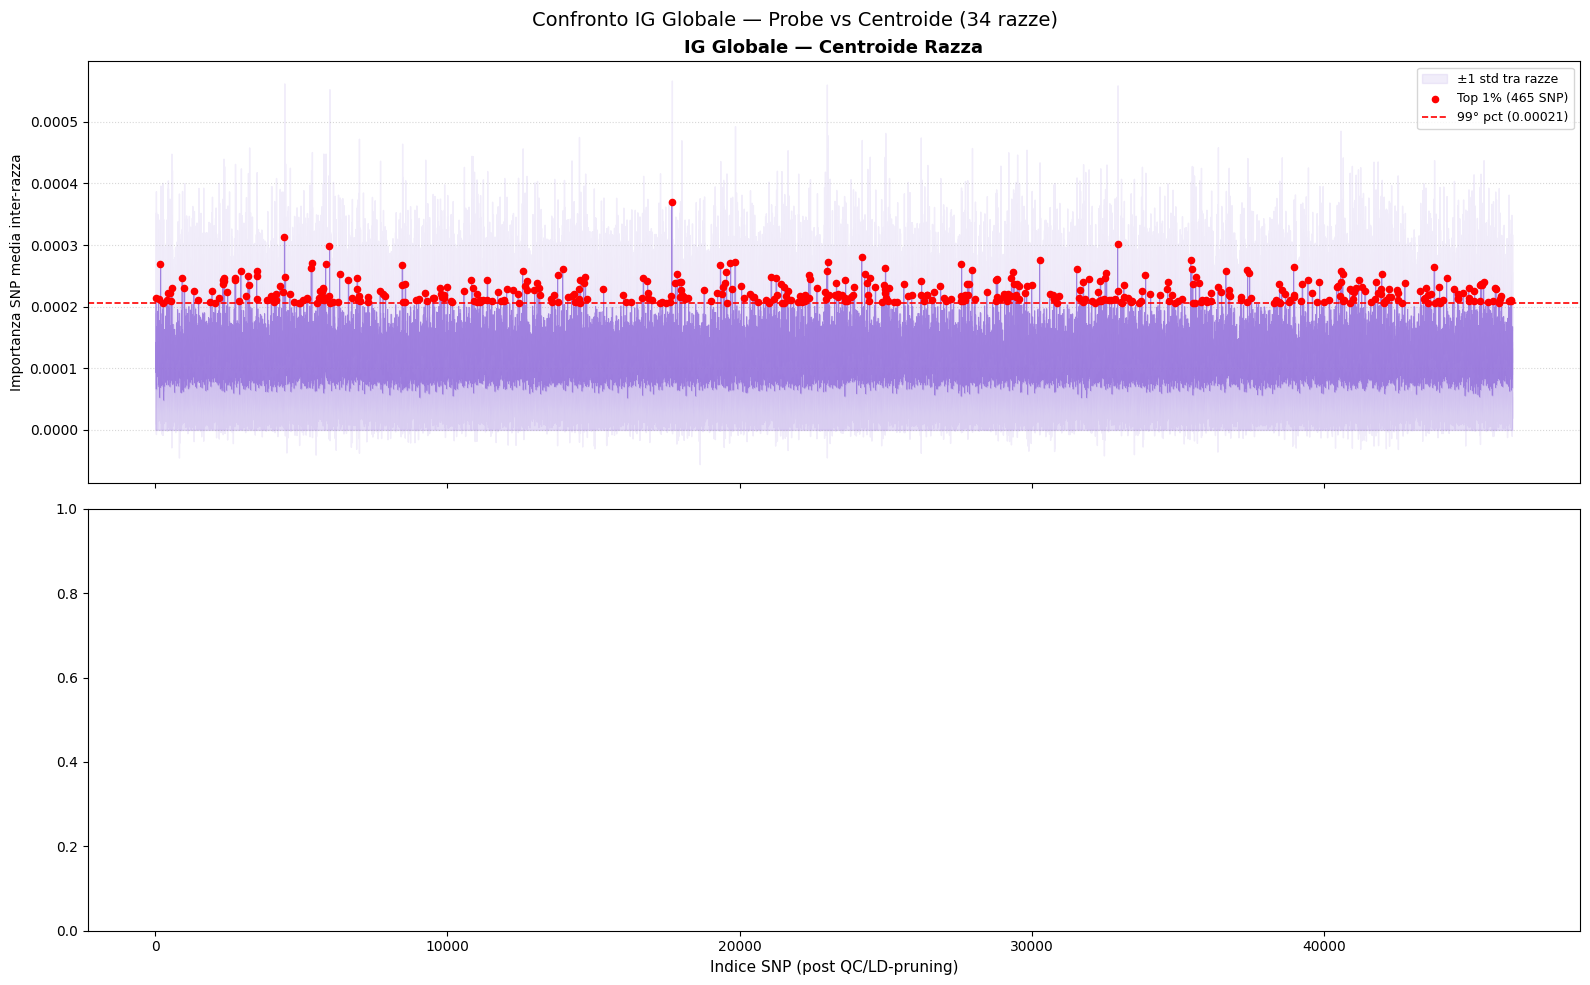

Salvato: results/ig_global_probe_vs_centroide.png

Top 20 SNP globali — Centroide (media su 34 razze):
Rank  SNP Index    IG mean          IG std         mean/std
-------------------------------------------------------
1     17683        0.00037020   0.00019674   1.88
2     4414         0.00031365   0.00024856   1.26
3     32943        0.00030222   0.00025681   1.18
4     5959         0.00029774   0.00025507   1.17
5     24185        0.00028072   0.00018970   1.48
6     30271        0.00027522   0.00015892   1.73
7     35451        0.00027514   0.00012751   2.16
8     23016        0.00027326   0.00020477   1.33
9     19845        0.00027273   0.00022016   1.24
10    5359         0.00027059   0.00018027   1.50
11    19688        0.00027058   0.00010619   2.55
12    27596        0.00026993   0.00011757   2.30
13    5826         0.00026922   0.00017912   1.50
14    172          0.00026919   0.00012730   2.11
15    8449         0.00026730   0.00019717   1.36
16    19340        0.00026728  

In [ ]:
# ============================================================
# IG SU COSINE SIMILARITY AL CENTROIDE DI RAZZA
# Approccio probe-free: misura diretta sulla geometria sferica
# ============================================================

import glob
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as tts
import torch.optim as optim

# ── Carica il miglior modello (riusa se già disponibile) ─────
if 'best_model' not in globals():
    print("⏳ Setup del DataModule necessario...")
    SAMPLES_PER_CLASS = 30
    BED_PATH = "../data/ADAPTmap_genotypeTOP_20160222_full.bed"
    dm = GenomicDataModule(
        bed_path              = BED_PATH,
        batch_size            = 512,
        maf_thresh            = 0.01,
        geno_thresh           = 0.1,
        min_samples_per_class = SAMPLES_PER_CLASS,
        ld_pruning            = True,
        ld_threshold          = 0.2,
        ld_window             = 50,
        val_split             = 0.15,
        test_split            = 0.15,
        downsample_per_class  = None,
    )
    dm.setup()

    checkpoints = glob.glob("checkpoints/Original/fold_*/epoch=*-val_loss=*.ckpt")
    best_ckpt_c, best_acc_c = None, -1
    for ckpt in checkpoints:
        m   = ContrastiveGeneticModel.load_from_checkpoint(ckpt)
        Z   = extract_embeddings(m, dm.X_processed)
        acc = compute_metrics(Z, dm.y_processed, k=3)['knn_acc_k3']
        if acc > best_acc_c:
            best_acc_c, best_ckpt_c = acc, ckpt
    best_model = ContrastiveGeneticModel.load_from_checkpoint(best_ckpt_c)
    device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    best_model = best_model.to(device)
    best_model.eval()
    print(f"Modello caricato: {best_ckpt_c}")
else:
    device = next(best_model.parameters()).device
    print("Riuso best_model già in memoria.")

# ── Calcola i centroidi di razza sulla sfera ─────────────────
with torch.no_grad():
    Z_all = extract_embeddings(best_model, dm.X_processed)   # (N, 3)

centroids = np.zeros((dm.num_classes, 3), dtype=np.float32)
for cls in range(dm.num_classes):
    mask = dm.y_processed == cls
    if mask.sum() > 0:
        c = Z_all[mask].mean(axis=0)
        centroids[cls] = c / (np.linalg.norm(c) + 1e-8)     # normalizza sulla sfera

centroids_t = torch.FloatTensor(centroids).to(device)        # (num_classes, 3)
print(f"Centroidi calcolati per {dm.num_classes} razze.")

# ── Wrapper probe-free: encoder → cosine similarity centroide ─
class EncoderToCentroid(nn.Module):
    '''
    Pipeline differenziabile probe-free:
        x_one_hot (B, M, 4)  →  encoder  →  z (B, 3)  →  cosine_sim verso centroide razza

    La cosine similarity su una sfera unitaria coincide con il dot product
    (entrambi i vettori sono gia normalizzati L2 dall'encoder).
    Restituisce shape (B,) — uno scalare per campione.
    '''
    def __init__(self, encoder, centroids):
        super().__init__()
        self.encoder   = encoder
        # centroids come parametro non addestrabile
        self.register_buffer('centroids', centroids)

    def forward(self, x_one_hot, target_class):
        z = self.encoder(x_one_hot)                          # (B, 3) normalizzato L2
        c = self.centroids[target_class].unsqueeze(0)        # (1, 3)
        return (z * c).sum(dim=1)                            # (B,) cosine similarity

enc_centroid = EncoderToCentroid(
    encoder   = best_model.encoder,
    centroids = centroids_t,
).to(device).eval()

# ── IG globale con centroide (batched) ────────────────────────
def compute_ig_centroid_batched(model, X_snps, target_classes,
                                 n_steps=50, batch_size=32):
    N, M   = X_snps.shape
    ig_all = np.zeros((N, M), dtype=np.float32)
    alphas = torch.linspace(0.0, 1.0, n_steps + 1, device=device)

    model.eval()
    for start in range(0, N, batch_size):
        end     = min(start + batch_size, N)
        B       = end - start
        x_batch = torch.FloatTensor(X_snps[start:end]).to(device)
        t_batch = target_classes[start:end]                  # (B,) indici classe

        with torch.no_grad():
            x_oh_b = GeneticAugmentation.one_hot_encode(x_batch).float()
        baseline = torch.zeros_like(x_oh_b)
        diff     = x_oh_b - baseline

        grads_list = []
        for alpha in alphas:
            interp = (baseline + alpha * diff).requires_grad_(True)
            # Seleziona il centroide corretto per ogni campione del batch
            c_batch = model.centroids[t_batch]               # (B, 3)
            z       = model.encoder(interp)                  # (B, 3)
            score   = (z * c_batch).sum(dim=1).sum()         # scalare
            model.zero_grad()
            score.backward()
            grads_list.append(interp.grad.detach().clone())

        gs        = torch.stack(grads_list)
        avg_grads = (gs[0] + gs[-1]) / 2.0 + gs[1:-1].sum(0)
        avg_grads /= n_steps

        ig_map            = diff * avg_grads
        ig_all[start:end] = ig_map.abs().sum(dim=-1).cpu().numpy()

        if (end % 256 == 0) or end == N:
            print(f"  {end}/{N} campioni elaborati...")

    return ig_all

N_IG_STEPS = 50
print("\nCalcolo IG centroide globale su tutti i campioni...")
ig_all_c = compute_ig_centroid_batched(
    model          = enc_centroid,
    X_snps         = dm.X_processed,
    target_classes = torch.LongTensor(dm.y_processed).to(device),
    n_steps        = N_IG_STEPS,
    batch_size     = 32,
)
print(f"ig_all_c shape: {ig_all_c.shape}")

# Media pesata per razza
ig_per_breed_c = []
for cls in range(dm.num_classes):
    mask = dm.y_processed == cls
    if mask.sum() > 0:
        ig_per_breed_c.append(ig_all_c[mask].mean(axis=0))

ig_global_c     = np.mean(ig_per_breed_c, axis=0)
ig_global_c_std = np.std(ig_per_breed_c,  axis=0)

import os
os.makedirs('results', exist_ok=True)
np.save('results/ig_centroid_global_mean.npy', ig_global_c)
np.save('results/ig_centroid_global_std.npy',  ig_global_c_std)
print("Salvato: results/ig_centroid_global_mean.npy")

# ── Plot comparativo globale: Probe MLP vs Centroide ─────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

datasets = [
    (ig_global,   ig_global_std,   'IG Globale — Probe MLP',      'mediumseagreen'),
    (ig_global_c, ig_global_c_std, 'IG Globale — Centroide Razza', 'mediumpurple'),
] if 'ig_global' in globals() else [
    (ig_global_c, ig_global_c_std, 'IG Globale — Centroide Razza', 'mediumpurple'),
]

for ax, (ig_vals, ig_std, title, color) in zip(axes, datasets):
    thr  = np.percentile(ig_vals, 99)
    hot  = ig_vals >= thr
    sidx = np.arange(len(ig_vals))
    ax.fill_between(sidx, ig_vals, alpha=0.25, color=color)
    ax.plot(sidx, ig_vals, lw=0.5, color=color, alpha=0.8)
    ax.fill_between(sidx,
                    ig_vals - ig_std, ig_vals + ig_std,
                    alpha=0.12, color=color, label='±1 std tra razze')
    ax.scatter(sidx[hot], ig_vals[hot], s=20, color='red', zorder=5,
               label=f'Top 1% ({hot.sum()} SNP)')
    ax.axhline(thr, color='red', linestyle='--', lw=1.2,
               label=f'99° pct ({thr:.5f})')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Importanza SNP media inter-razza', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

axes[-1].set_xlabel('Indice SNP (post QC/LD-pruning)', fontsize=11)
plt.suptitle(f'Confronto IG Globale — Probe vs Centroide ({dm.num_classes} razze)',
             fontsize=14)
plt.tight_layout()
plt.savefig('results/ig_global_probe_vs_centroide.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: results/ig_global_probe_vs_centroide.png")

# ── Jaccard globale: Probe MLP vs Centroide ───────────────────
if 'ig_global' in globals():
    top_g_probe    = set(np.where(ig_global   >= np.percentile(ig_global,   99))[0])
    top_g_centroid = set(np.where(ig_global_c >= np.percentile(ig_global_c, 99))[0])
    jacc_global    = len(top_g_probe & top_g_centroid) / len(top_g_probe | top_g_centroid)
    print(f"\nJaccard globale Probe MLP vs Centroide: {jacc_global:.4f}")
    print(f"  Probe:     {len(top_g_probe)} SNP")
    print(f"  Centroide: {len(top_g_centroid)} SNP")
    print(f"  Intersezione: {len(top_g_probe & top_g_centroid)} SNP")

# ── Top 20 SNP globali centroide ──────────────────────────────
top20_gc = np.argsort(ig_global_c)[::-1][:20]
print(f"\nTop 20 SNP globali — Centroide (media su {dm.num_classes} razze):")
print(f"{'Rank':<5} {'SNP Index':<12} {'IG mean':<16} {'IG std':<14} {'mean/std'}")
print('-' * 55)
for rank, idx in enumerate(top20_gc, 1):
    snr = ig_global_c[idx] / (ig_global_c_std[idx] + 1e-10)
    print(f"{rank:<5} {idx:<12} {ig_global_c[idx]:.8f}   "
          f"{ig_global_c_std[idx]:.8f}   {snr:.2f}")


Baseline full dataset...
  KNN: 0.6136
  LR: 0.9728
  RF: 0.8370

Top 0.1% (47 SNP):
  KNN IG: 0.6032
  LR IG: 0.6929
  RF IG: 0.6596
  KNN rand: 0.5839 ± 0.0110
  LR rand: 0.6718 ± 0.0071
  RF rand: 0.6000 ± 0.0116

Top 0.5% (233 SNP):
  KNN IG: 0.7587
  LR IG: 0.9079
  RF IG: 0.7964
  KNN rand: 0.6546 ± 0.0120
  LR rand: 0.8943 ± 0.0018
  RF rand: 0.7356 ± 0.0094

Top 1.0% (465 SNP):
  KNN IG: 0.7604
  LR IG: 0.9459
  RF IG: 0.8007
  KNN rand: 0.6478 ± 0.0183
  LR rand: 0.9366 ± 0.0020
  RF rand: 0.7642 ± 0.0067

Top 2.0% (930 SNP):
  KNN IG: 0.7611
  LR IG: 0.9590
  RF IG: 0.8233
  KNN rand: 0.6350 ± 0.0063
  LR rand: 0.9579 ± 0.0014
  RF rand: 0.7851 ± 0.0062

Top 5.0% (2323 SNP):
  KNN IG: 0.7325
  LR IG: 0.9688
  RF IG: 0.8367
  KNN rand: 0.6238 ± 0.0084
  LR rand: 0.9677 ± 0.0011
  RF rand: 0.8052 ± 0.0037

Top 10.0% (4646 SNP):
  KNN IG: 0.7009
  LR IG: 0.9731
  RF IG: 0.8364
  KNN rand: 0.6249 ± 0.0047
  LR rand: 0.9722 ± 0.0014
  RF rand: 0.8161 ± 0.0046

Salvato: results/ig_

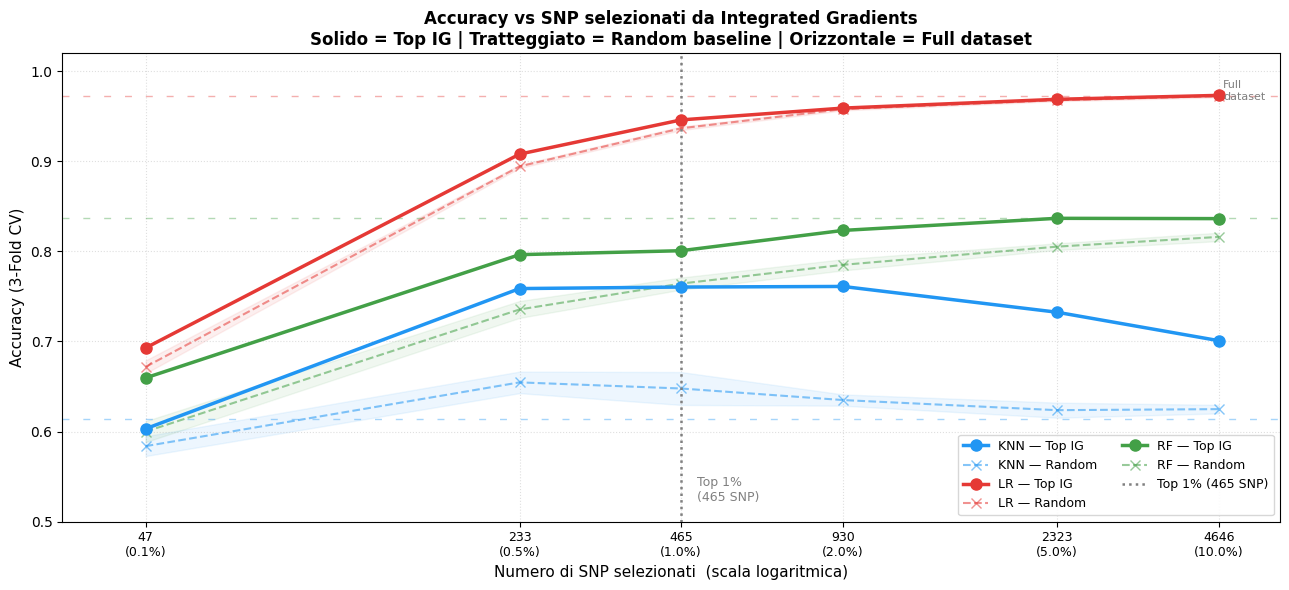

Salvato: results/ig_accuracy_curve.png


In [ ]:
# ============================================================
# CURVA ACCURACY vs SOGLIA TOP % IG
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import plotly.graph_objects as go
import json, os

# ── Configurazione ────────────────────────────────────────────
PERCENTILES    = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
CV_FOLDS       = 3
N_RANDOM_SEEDS = 5    # baseline random per ogni soglia

ig_scores = ig_global_c   # usa centroide — più fedele alla geometria
X_full    = dm.X_processed
y_all     = dm.y_processed
skf       = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

classifiers = {
    'KNN':  KNeighborsClassifier(n_neighbors=3),
    'LR':   LogisticRegression(max_iter=1000, C=1.0,
                                multi_class='multinomial',
                                solver='lbfgs', random_state=42),
    'RF':   RandomForestClassifier(n_estimators=200,
                                    random_state=42, n_jobs=-1),
}

# ── Baseline full dataset (calcolata una volta) ───────────────
print("Baseline full dataset...")
scaler_full = StandardScaler()
X_full_s    = scaler_full.fit_transform(X_full)
acc_full    = {}
for name, clf in classifiers.items():
    s = cross_val_score(clf, X_full_s, y_all, cv=skf,
                        scoring='accuracy', n_jobs=-1).mean()
    acc_full[name] = s
    print(f"  {name}: {s:.4f}")

# ── Ciclo su percentili ───────────────────────────────────────
results = []
for pct in PERCENTILES:
    threshold = np.percentile(ig_scores, 100 - pct)
    idx       = np.where(ig_scores >= threshold)[0]
    n_snp     = len(idx)
    X_sub     = X_full[:, idx]
    X_sub_s   = StandardScaler().fit_transform(X_sub)

    row = {'percentile': pct, 'n_snp': n_snp}
    print(f"\nTop {pct}% ({n_snp} SNP):")

    # Top IG accuracy
    for name, clf in classifiers.items():
        s = cross_val_score(clf, X_sub_s, y_all, cv=skf,
                            scoring='accuracy', n_jobs=-1).mean()
        row[f'acc_{name}_ig'] = s
        print(f"  {name} IG: {s:.4f}")

    # Random baseline (N_RANDOM_SEEDS trial)
    for name in classifiers:
        rand_accs = []
        for seed in range(N_RANDOM_SEEDS):
            np.random.seed(seed)
            ri  = np.random.choice(X_full.shape[1], n_snp, replace=False)
            Xr  = StandardScaler().fit_transform(X_full[:, ri])
            clf = list(classifiers.values())[list(classifiers.keys()).index(name)]
            s   = cross_val_score(clf, Xr, y_all, cv=skf,
                                   scoring='accuracy', n_jobs=-1).mean()
            rand_accs.append(s)
        row[f'acc_{name}_rand_mean'] = np.mean(rand_accs)
        row[f'acc_{name}_rand_std']  = np.std(rand_accs)
        print(f"  {name} rand: {np.mean(rand_accs):.4f} ± {np.std(rand_accs):.4f}")

    results.append(row)

df_curve = pd.DataFrame(results)
os.makedirs('results', exist_ok=True)
df_curve.to_csv('results/ig_accuracy_curve.csv', index=False)
print("\nSalvato: results/ig_accuracy_curve.csv")

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

clf_colors = {'KNN': '#2196F3', 'LR': '#E53935', 'RF': '#43A047'}

fig, ax = plt.subplots(figsize=(13, 6))

for name, color in clf_colors.items():
    # Linea Top IG — solida
    ax.plot(df_curve['n_snp'], df_curve[f'acc_{name}_ig'],
            'o-', color=color, linewidth=2.5, markersize=8,
            label=f'{name} — Top IG', zorder=3)

    # Banda errore random (mean ± std)
    rand_mean = df_curve[f'acc_{name}_rand_mean']
    rand_std  = df_curve[f'acc_{name}_rand_std']
    ax.plot(df_curve['n_snp'], rand_mean,
            'x--', color=color, linewidth=1.5, markersize=7,
            alpha=0.55, label=f'{name} — Random')
    ax.fill_between(df_curve['n_snp'],
                    rand_mean - rand_std, rand_mean + rand_std,
                    color=color, alpha=0.08)

    # Baseline full dataset — tratteggiata orizzontale
    ax.axhline(acc_full[name], color=color,
               linestyle=(0, (5, 10)), linewidth=1.0, alpha=0.4)

# Linea verticale Top 1% (465 SNP)
ax.axvline(x=465, color='gray', linestyle=':', linewidth=1.8,
           label='Top 1% (465 SNP)', zorder=2)
ax.text(465 * 1.07, 0.52, 'Top 1%\n(465 SNP)',
        color='gray', fontsize=9, va='bottom')

# Annotazione baseline full (una sola, a destra)
ax.text(df_curve['n_snp'].max() * 1.02, acc_full['LR'] + 0.005,
        'Full\ndataset', fontsize=8, color='gray', va='center')

ax.set_xscale('log')
ax.set_xlim(df_curve['n_snp'].min() * 0.7,
            df_curve['n_snp'].max() * 1.3)
ax.set_ylim(0.50, 1.02)

# Tick asse X con percentuale e n SNP
ax.set_xticks(df_curve['n_snp'])
ax.set_xticklabels(
    [f"{int(r['n_snp'])}\n({r['percentile']}%)"
     for _, r in df_curve.iterrows()],
    fontsize=9
)
ax.xaxis.set_minor_locator(ticker.NullLocator())

ax.set_xlabel('Numero di SNP selezionati  (scala logaritmica)', fontsize=11)
ax.set_ylabel('Accuracy (3-Fold CV)', fontsize=11)
ax.set_title('Accuracy vs SNP selezionati da Integrated Gradients\n'
             'Solido = Top IG | Tratteggiato = Random baseline | '
             'Orizzontale = Full dataset',
             fontsize=12, fontweight='bold')

ax.legend(loc='lower right', fontsize=9, ncol=2,
          framealpha=0.9, edgecolor='lightgray')
ax.grid(True, which='major', linestyle=':', alpha=0.4)
ax.grid(False, which='minor')

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/ig_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: results/ig_accuracy_curve.png")